In [1]:
# Import necessary libraries for data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# We will import specific Machine Learning tools later when we need them
import time # Used to track how long our models take to train
import warnings
warnings.filterwarnings('ignore') # This hides unnecessary warning messages

In [2]:
# Load the dataset we prepared in the previous notebook
dataset_path = './processed_invoice_dataset.csv'
invoice_data = pd.read_csv(dataset_path)

# 1. Display the shape (number of rows and columns)
print("Dataset Shape:")
print(f"Rows: {invoice_data.shape[0]}, Columns: {invoice_data.shape[1]}\n")

# 2. Display the first five rows to see what the data looks like
print("First 5 rows of the dataset:")
display(invoice_data.head())

# 3. Display the feature names (columns)
print("\nFeature Names (Columns):")
for column_name in invoice_data.columns:
    print("-", column_name)

# 4. Display the target distribution
# Assuming our target variable is named 'is_fraud' (0 = Normal, 1 = Fraud)
print("\nTarget Variable Distribution (is_fraud):")
target_counts = invoice_data['is_fraud'].value_counts()
print(target_counts)

# Let's also see it as percentages
print("\nTarget Variable Percentages:")
print(invoice_data['is_fraud'].value_counts(normalize=True) * 100)

Dataset Shape:
Rows: 14760, Columns: 54

First 5 rows of the dataset:


,vendor_category,country,city,department,payment_terms,currency,amount,tax_rate,tax_amount,is_fraud,...,category_median_amount,category_spend,amount_vs_vendor_average,amount_above_average,duplicate_invoice_flag,duplicate_po_flag,high_tax_flag,low_tax_flag,new_vendor_flag,weekend_invoice_flag
0,1,2,55,4,30,3,368659.03,0.1388,51169.87,1,...,43311.65,70454120.26,3.571277,1,0,1,0,0,0,0
1,1,2,55,4,30,3,75588.68,0.1388,10491.71,0,...,43311.65,70454120.26,0.732243,0,0,1,0,0,0,0
2,1,2,55,4,30,3,76126.01,0.1388,10566.29,0,...,43311.65,70454120.26,0.737449,0,0,1,0,0,0,0
3,1,2,55,7,30,3,98334.87,0.1388,13648.88,1,...,43311.65,70454120.26,0.952591,0,0,1,0,0,0,0
4,1,2,55,7,30,3,63983.73,0.1388,8880.94,0,...,43311.65,70454120.26,0.619824,0,0,1,0,0,0,0



Feature Names (Columns):
- vendor_category
- country
- city
- department
- payment_terms
- currency
- amount
- tax_rate
- tax_amount
- is_fraud
- invoice_year
- invoice_month
- invoice_day
- invoice_weekday
- invoice_quarter
- days_until_due
- invoice_age
- amount_log
- tax_percentage
- amount_per_day
- rounded_amount_flag
- high_value_invoice
- vendor_invoice_count
- vendor_total_spend
- vendor_average_amount
- vendor_median_amount
- vendor_max_amount
- vendor_min_amount
- vendor_std_amount
- vendor_unique_departments
- days_since_last_invoice
- previous_invoice_amount
- amount_difference
- amount_ratio
- rolling_average_3
- rolling_average_5
- rolling_std
- department_invoice_count
- department_average_amount
- department_total_spend
- payment_days
- late_payment_risk
- category_invoice_count
- category_average_amount
- category_median_amount
- category_spend
- amount_vs_vendor_average
- amount_above_average
- duplicate_invoice_flag
- duplicate_po_flag
- high_tax_flag
- low_tax_flag

In [3]:
# Create the features dataset (X) by dropping the target column
# axis=1 means we are dropping a column (not a row)
X = invoice_data.drop('is_fraud', axis=1)

# Create the target dataset (y) by selecting ONLY the target column
y = invoice_data['is_fraud']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

Features (X) shape: (14760, 53)
Target (y) shape: (14760,)


In [4]:
from sklearn.model_selection import train_test_split

# We split the data into 80% training and 20% testing
# random_state=42 ensures that every time we run this code, we get the exact same split
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.20, 
    random_state=42
)

# Print the shapes to confirm the split
print("Training data shape (Features):", X_train.shape)
print("Training data shape (Target):", y_train.shape)
print("Testing data shape (Features):", X_test.shape)
print("Testing data shape (Target):", y_test.shape)

Training data shape (Features): (11808, 53)
Training data shape (Target): (11808,)
Testing data shape (Features): (2952, 53)
Testing data shape (Target): (2952,)


In [5]:
from sklearn.preprocessing import StandardScaler

# Create the scaler object
scaler = StandardScaler()

# Fit the scaler ON THE TRAINING DATA ONLY, and then transform it
# (We don't fit on test data to avoid data leakage)
X_train_scaled = scaler.fit_transform(X_train)

# Transform the test data using the rules learned from the training data
X_test_scaled = scaler.transform(X_test)

print("Scaling complete! We will save X_train_scaled for Logistic Regression.")

Scaling complete! We will save X_train_scaled for Logistic Regression.


In [6]:
from sklearn.linear_model import LogisticRegression

# 1. Initialize the model
logistic_model = LogisticRegression(random_state=42)

# Start tracking time
start_time = time.time()

# 2. Train the model using the SCALED training data
print("Training Logistic Regression...")
logistic_model.fit(X_train_scaled, y_train)

# Stop tracking training time
lr_train_time = time.time() - start_time
print(f"Training complete in {lr_train_time:.2f} seconds.")

# Start tracking inference (prediction) time
start_time = time.time()

# 3. Make predictions on the SCALED testing data
# predict() gives us the exact label (0 or 1)
lr_predictions = logistic_model.predict(X_test_scaled)

# predict_proba() gives us the probability (e.g., 85% chance of fraud)
lr_probabilities = logistic_model.predict_proba(X_test_scaled)[:, 1]

# Stop tracking inference time
lr_inference_time = time.time() - start_time

Training Logistic Regression...
Training complete in 0.06 seconds.


In [7]:
from sklearn.ensemble import RandomForestClassifier

# 1. Initialize the model
# We do not need to use scaled data for Random Forest!
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)

start_time = time.time()

# 2. Train the model using the UNSCALED training data
print("Training Random Forest...")
rf_model.fit(X_train, y_train)

rf_train_time = time.time() - start_time
print(f"Training complete in {rf_train_time:.2f} seconds.")

start_time = time.time()

# 3. Make predictions on the UNSCALED testing data
rf_predictions = rf_model.predict(X_test)
rf_probabilities = rf_model.predict_proba(X_test)[:, 1]

rf_inference_time = time.time() - start_time

Training Random Forest...
Training complete in 3.21 seconds.


In [8]:
import xgboost as xgb

# 1. Initialize XGBoost with beginner-friendly parameters
xgb_model = xgb.XGBClassifier(
    random_state=42,
    max_depth=5,              # How deep the trees can grow (controls complexity)
    learning_rate=0.1,        # How fast the model learns
    n_estimators=200,         # Total number of trees to build
    subsample=0.8,            # Use 80% of rows per tree to prevent overfitting
    colsample_bytree=0.8,     # Use 80% of columns per tree
    eval_metric='logloss'     # Standard evaluation metric for classification
)

start_time = time.time()

# 2. Train the model
print("Training XGBoost...")
xgb_model.fit(X_train, y_train)

xgb_train_time = time.time() - start_time
print(f"Training complete in {xgb_train_time:.2f} seconds.")

start_time = time.time()

# 3. Make predictions
# Predict labels (0 or 1)
xgb_predictions = xgb_model.predict(X_test)

# Predict probabilities (0.0 to 1.0)
xgb_probabilities = xgb_model.predict_proba(X_test)[:, 1]

xgb_inference_time = time.time() - start_time

Training XGBoost...
Training complete in 0.37 seconds.


In [9]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.metrics import confusion_matrix, classification_report

# Let's create a reusable function to evaluate models so we don't repeat code
def evaluate_model(model_name, y_true, y_pred, y_prob):
    print(f"\n{'='*40}")
    print(f"EVALUATION FOR: {model_name}")
    print(f"{'='*40}")
    
    # Calculate metrics
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)
    
    # Print metrics neatly
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"ROC AUC:   {roc_auc:.4f}")
    print(f"PR AUC:    {pr_auc:.4f}")
    
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))
    
    # Return metrics as a dictionary to use later in our comparison table
    return {
        'Model': model_name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1': f1,
        'ROC AUC': roc_auc,
        'PR AUC': pr_auc
    }

# Evaluate Logistic Regression
lr_metrics = evaluate_model("Logistic Regression", y_test, lr_predictions, lr_probabilities)

# Evaluate Random Forest
rf_metrics = evaluate_model("Random Forest", y_test, rf_predictions, rf_probabilities)

# Evaluate XGBoost
xgb_metrics = evaluate_model("XGBoost", y_test, xgb_predictions, xgb_probabilities)


EVALUATION FOR: Logistic Regression
Accuracy:  0.9258
Precision: 0.9651
Recall:    0.6160
F1 Score:  0.7520
ROC AUC:   0.8920
PR AUC:    0.8169

Confusion Matrix:
[[2401   12]
 [ 207  332]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96      2413
           1       0.97      0.62      0.75       539

    accuracy                           0.93      2952
   macro avg       0.94      0.81      0.85      2952
weighted avg       0.93      0.93      0.92      2952


EVALUATION FOR: Random Forest
Accuracy:  0.9387
Precision: 0.9661
Recall:    0.6883
F1 Score:  0.8039
ROC AUC:   0.9027
PR AUC:    0.8421

Confusion Matrix:
[[2400   13]
 [ 168  371]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      2413
           1       0.97      0.69      0.80       539

    accuracy                           0.94      2952
   macro avg       0.95      0.

In [10]:
# Create a list of dictionaries containing all our metrics
all_metrics = [lr_metrics, rf_metrics, xgb_metrics]

# Convert the list to a pandas DataFrame for a beautiful table
comparison_table = pd.DataFrame(all_metrics)

# Add the timing metrics we captured earlier
comparison_table['Training Time (sec)'] = [lr_train_time, rf_train_time, xgb_train_time]
comparison_table['Inference Time (sec)'] = [lr_inference_time, rf_inference_time, xgb_inference_time]

# Display the final comparison table
print("MODEL COMPARISON TABLE:")
display(comparison_table)

MODEL COMPARISON TABLE:


,Model,Accuracy,Precision,Recall,F1,ROC AUC,PR AUC,Training Time (sec),Inference Time (sec)
0,Logistic Regression,0.925813,0.965116,0.615955,0.751982,0.892000,0.816919,0.060835,0.001024
1,Random Forest,0.938686,0.966146,0.688312,0.803900,0.902736,0.842135,3.207568,0.069626
2,XGBoost,0.935976,0.955729,0.680891,0.795233,0.911228,0.851145,0.369879,0.089733


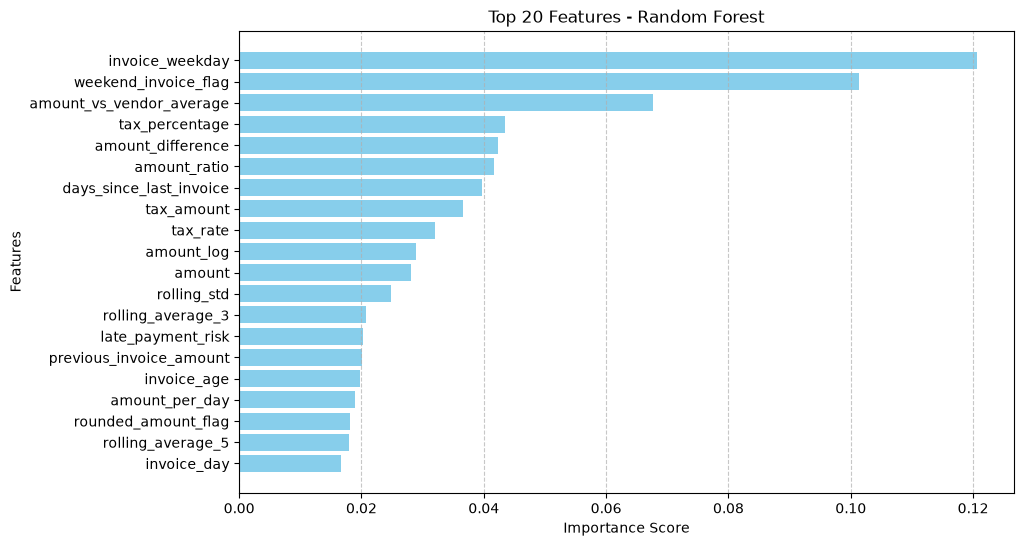

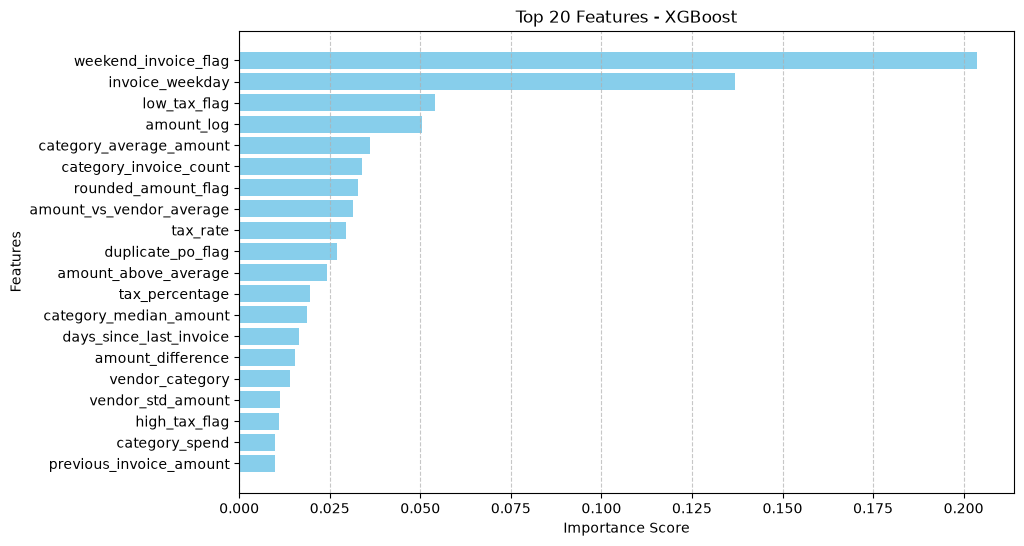

In [11]:
# Create a function to plot feature importance so we don't repeat code
def plot_feature_importance(model, feature_names, model_name):
    # Extract importance values from the model
    importances = model.feature_importances_
    
    # Create a DataFrame to hold feature names and their importance scores
    feat_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    
    # Sort the features by importance (highest at the top)
    # We only take the top 20 (.head(20))
    feat_df = feat_df.sort_values(by='Importance', ascending=True).tail(20)
    
    # Plotting
    plt.figure(figsize=(10, 6))
    plt.barh(feat_df['Feature'], feat_df['Importance'], color='skyblue')
    plt.title(f'Top 20 Features - {model_name}')
    plt.xlabel('Importance Score')
    plt.ylabel('Features')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.show()

# 1. Show Top 20 Features for Random Forest
plot_feature_importance(rf_model, X_train.columns, "Random Forest")

# 2. Show Top 20 Features for XGBoost
plot_feature_importance(xgb_model, X_train.columns, "XGBoost")

In [12]:
from sklearn.model_selection import RandomizedSearchCV

print("Starting Hyperparameter Tuning for XGBoost...")
print("This may take a few minutes. Please wait...\n")

# 1. Define the grid of parameters we want to test
param_grid = {
    'max_depth': [3, 5, 7, 10],                 # Depth of trees
    'learning_rate': [0.01, 0.05, 0.1, 0.2],    # Speed of learning
    'n_estimators': [100, 200, 300, 500, 700],       # Number of trees
    'subsample': [0.6, 0.8, 1.0],               # Row sampling
    'colsample_bytree': [0.6, 0.8, 1.0]         # Column sampling
}

# 2. Initialize a base XGBoost model
base_xgb = xgb.XGBClassifier(random_state=42, eval_metric='logloss')

# 3. Setup the Randomized Search
# cv = 5 means 5-fold cross validation (tests reliability)
# scoring = 'recall' because catching fraud is our #1 priority
# n_iter = 20 means it will test 20 random combinations
random_search = RandomizedSearchCV(
    estimator=base_xgb,
    param_distributions=param_grid,
    n_iter=50,
    scoring='recall',
    cv=5,
    random_state=42,
    verbose=1,
    n_jobs=-1 # Uses all CPU cores to run faster
)

# 4. Run the search on the training data
random_search.fit(X_train, y_train)

# 5. Print the winning results
print("\n--- Tuning Complete! ---")
print("Best Parameters Found:")
for param, value in random_search.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nBest Recall Score during cross-validation: {random_search.best_score_:.4f}")

# 6. Train the final, optimized model automatically
# (RandomizedSearchCV automatically saves the best model inside .best_estimator_)
final_xgb_model = random_search.best_estimator_

# Let's quickly see how the tuned model performs on the test set
tuned_predictions = final_xgb_model.predict(X_test)
print(f"Tuned Model Test Recall: {recall_score(y_test, tuned_predictions):.4f}")

Starting Hyperparameter Tuning for XGBoost...
This may take a few minutes. Please wait...

Fitting 5 folds for each of 50 candidates, totalling 250 fits

--- Tuning Complete! ---
Best Parameters Found:
  subsample: 0.8
  n_estimators: 700
  max_depth: 5
  learning_rate: 0.2
  colsample_bytree: 0.8

Best Recall Score during cross-validation: 0.6839
Tuned Model Test Recall: 0.7032


1. SHAP Summary Plot (Beeswarm)
How to read: Red dots mean HIGH feature value. Blue dots mean LOW. 
Dots pushed to the right mean higher risk of fraud.


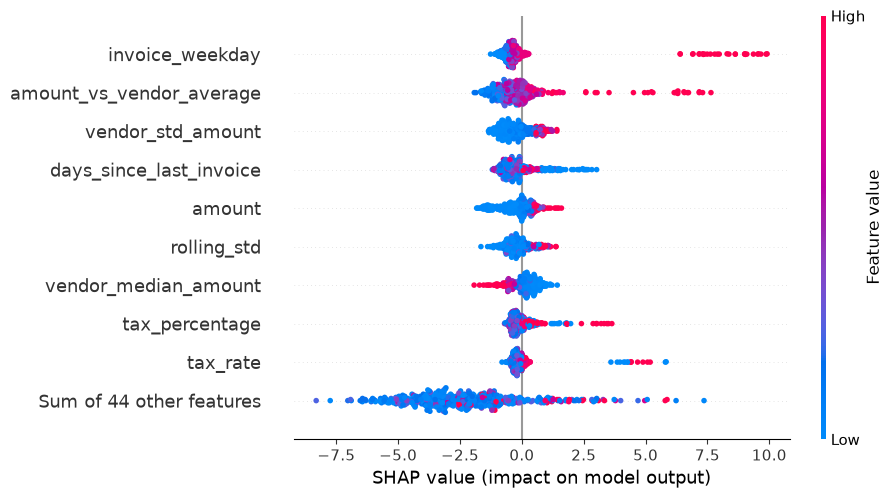


2. SHAP Global Bar Plot
How to read: Average absolute impact of each feature on predictions.


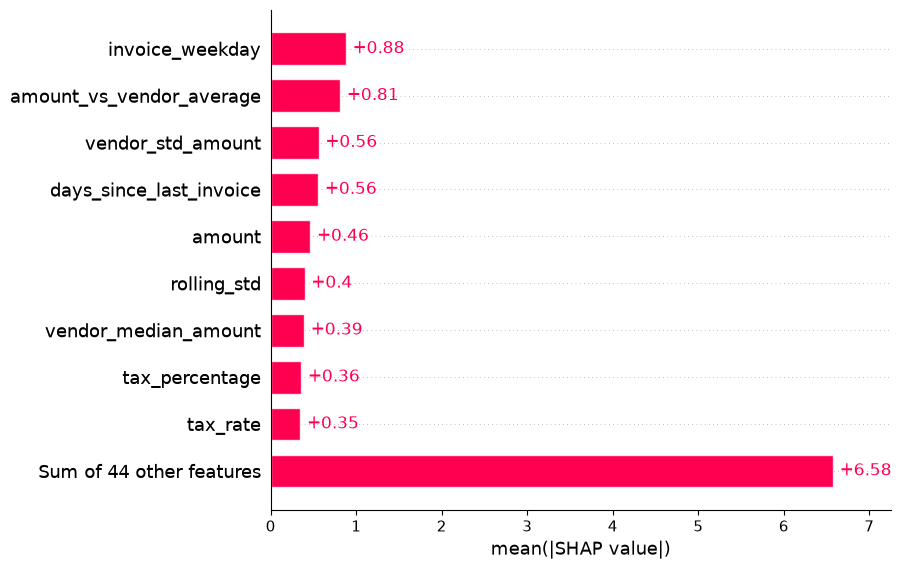


3. SHAP Waterfall Plot (For a single invoice)
How to read: We start at the base expectation (bottom). 
Red bars push the probability towards Fraud. Blue bars push towards Normal. 
The top is the final prediction.


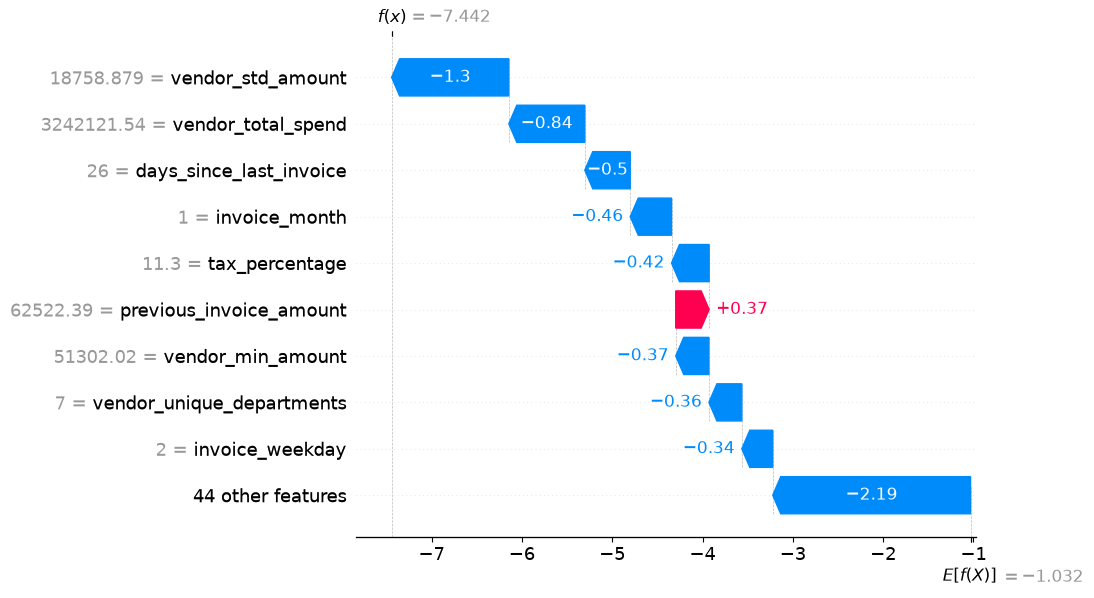


4. SHAP Force Plot (Interactive alternative to waterfall)


In [18]:
import shap

# Initialize JavaScript visualization code for SHAP
shap.initjs()

# 1. Create the SHAP Explainer using our final XGBoost model
explainer = shap.TreeExplainer(final_xgb_model)

# Calculate SHAP values for the test dataset
# (We use a sample of 500 to compute it faster for this tutorial)
X_test_sample = X_test.sample(n=500, random_state=42)
shap_values = explainer(X_test_sample)

# --- VISUALIZATION 1: SUMMARY PLOT ---
# The Summary Plot shows the most important features globally, 
# and whether high/low values of that feature push the prediction toward fraud.
print("1. SHAP Summary Plot (Beeswarm)")
print("How to read: Red dots mean HIGH feature value. Blue dots mean LOW. \nDots pushed to the right mean higher risk of fraud.")
shap.plots.beeswarm(shap_values)

# --- VISUALIZATION 2: BAR PLOT ---
# The Bar Plot is a simpler version of global feature importance.
print("\n2. SHAP Global Bar Plot")
print("How to read: Average absolute impact of each feature on predictions.")
shap.plots.bar(shap_values)

# --- VISUALIZATION 3: WATERFALL PLOT ---
# Explaining a SINGLE invoice prediction.
print("\n3. SHAP Waterfall Plot (For a single invoice)")
print("How to read: We start at the base expectation (bottom). \nRed bars push the probability towards Fraud. Blue bars push towards Normal. \nThe top is the final prediction.")
# We explain the very first invoice in our sample
shap.plots.waterfall(shap_values[0])

# --- VISUALIZATION 4: FORCE PLOT (Optional but useful) ---
print("\n4. SHAP Force Plot (Interactive alternative to waterfall)")
shap.plots.force(shap_values[0])

In [19]:
import joblib

# 1. Save the final optimized XGBoost model
joblib.dump(final_xgb_model, 'fraud_model.pkl')

# 2. Save the Scaler (even though XGBoost doesn't need it, we save it 
# in case we ever want to run Logistic Regression in the future)
joblib.dump(scaler, 'scaler.pkl')

# Note: If we had a LabelEncoder from preprocessing, we would save it here too:
# joblib.dump(label_encoder, 'label_encoder.pkl')

print("Models saved successfully to your hard drive!")
print("- fraud_model.pkl")
print("- scaler.pkl")

Models saved successfully to your hard drive!
- fraud_model.pkl
- scaler.pkl


In [20]:
import joblib
# Select one random invoice from our test set
random_index = 42 # Chosen arbitrarily 
single_invoice_features = X_test.iloc[[random_index]]
actual_label = y_test.iloc[random_index]

print("single_invoice_features",single_invoice_features)
print("actual_label",actual_label)
# Load the saved model (just to prove it works from the file!)
loaded_model = joblib.load('fraud_model.pkl')

# Predict probability
predicted_prob = loaded_model.predict_proba(single_invoice_features)[0][1]

# Predict label
predicted_label = loaded_model.predict(single_invoice_features)[0]

print("--- SINGLE INVOICE PREDICTION TEST ---")
print(f"Invoice Data:")
# Just showing first 5 features for brevity
print(single_invoice_features.iloc[:, :5].to_string(index=False)) 

print(f"\nModel Predicted Probability: {predicted_prob * 100:.2f}% chance of fraud")

# Explaining prediction output
if predicted_label == 1:
    str_prediction = "FRAUD"
else:
    str_prediction = "NORMAL"

if actual_label == 1:
    str_actual = "FRAUD"
else:
    str_actual = "NORMAL"

print(f"Model Predicted Label:       {str_prediction} ({predicted_label})")
print(f"Actual Truth Label:          {str_actual} ({actual_label})")

if predicted_label == actual_label:
    print("\n✅ The model was CORRECT!")
else:
    print("\n❌ The model was WRONG.")

single_invoice_features       vendor_category  country  city  department  payment_terms  currency  \
4333                6        2   198           5             45         3   

        amount  tax_rate  tax_amount  invoice_year  ...  \
4333  12836.44      0.07      898.55          2024  ...   

      category_median_amount  category_spend  amount_vs_vendor_average  \
4333                11323.27     49540973.17                  0.914714   

      amount_above_average  duplicate_invoice_flag  duplicate_po_flag  \
4333                     0                       0                  1   

      high_tax_flag  low_tax_flag  new_vendor_flag  weekend_invoice_flag  
4333              0             0                0                     0  

[1 rows x 53 columns]
actual_label 0
--- SINGLE INVOICE PREDICTION TEST ---
Invoice Data:
 vendor_category  country  city  department  payment_terms
               6        2   198           5             45

Model Predicted Probability: 0.37% chance of f

In [21]:
print("==================================================")
print("          PROJECT FINAL SUMMARY REPORT            ")
print("==================================================")

# Gather stats
total_samples = invoice_data.shape[0]
train_samples = X_train.shape[0]
test_samples = X_test.shape[0]
total_features = X_train.shape[1]

# Extracting best metrics for display (assuming XGBoost was best)
best_model_name = "XGBoost (Tuned)"
best_recall = recall_score(y_test, tuned_predictions)
best_precision = precision_score(y_test, tuned_predictions)
best_roc_auc = roc_auc_score(y_test, final_xgb_model.predict_proba(X_test)[:, 1])

print(f"Total Samples Processed:      {total_samples:,}")
print(f"Training Samples:             {train_samples:,}")
print(f"Testing Samples:              {test_samples:,}")
print(f"Total Features Used:          {total_features}")
print("-" * 50)
print(f"Best Model Selected:          {best_model_name}")
print(f"Best Recall Score:            {best_recall:.4f}")
print(f"Best Precision Score:         {best_precision:.4f}")
print(f"Best ROC AUC Score:           {best_roc_auc:.4f}")
print("-" * 50)
print(f"Total Training Time (approx): {xgb_train_time:.2f} seconds")
print(f"Model Saved Successfully:     Yes (fraud_model.pkl)")
print("==================================================")
print("Fantastic job! You are well on your way to becoming a Machine Learning Engineer.")

          PROJECT FINAL SUMMARY REPORT            
Total Samples Processed:      14,760
Training Samples:             11,808
Testing Samples:              2,952
Total Features Used:          53
--------------------------------------------------
Best Model Selected:          XGBoost (Tuned)
Best Recall Score:            0.7032
Best Precision Score:         0.9089
Best ROC AUC Score:           0.9030
--------------------------------------------------
Total Training Time (approx): 0.37 seconds
Model Saved Successfully:     Yes (fraud_model.pkl)
Fantastic job! You are well on your way to becoming a Machine Learning Engineer.


## Raw Testing

In [17]:
import pandas as pd
import numpy as np
import joblib

print("--- SIMULATING LIVE INVOICE SYSTEM ---\n")

# 1. Load our saved model
print("Loading saved model...")
live_model = joblib.load('fraud_model.pkl')
print("Model loaded successfully!\n")

# 2. THE FIX: Ask the model exactly what columns it expects
# feature_names_in_ is a saved list of the exact 53 columns from X_train
expected_columns = live_model.feature_names_in_

# 3. Create a DataFrame with 1 row, where every column is currently filled with 0.0
# This guarantees we have the exact right number of columns and perfect spelling!
new_invoice_df = pd.DataFrame(np.zeros((1, len(expected_columns))), columns=expected_columns)

# 4. Now, let's inject some suspicious data into specific columns
# (You can change these values to see how the model reacts!)
new_invoice_df['amount'] = 85000.00             # Unusually high amount
new_invoice_df['tax_amount'] = 0.0              # No tax applied
new_invoice_df['new_vendor_flag'] = 1.0         # This is a brand new vendor
new_invoice_df['weekend_invoice_flag'] = 1.0    # Submitted on a weekend
new_invoice_df['high_value_invoice'] = 1.0      # Flagged as high value
new_invoice_df['amount_difference'] = 50000.00  # Way higher than their usual invoices

# Let's peek at the first 10 columns of our perfectly formatted fake data
print("New Invoice Data Formatted for Model (First 10 columns):")
display(new_invoice_df.iloc[:, :10])

# 5. Make the prediction
# predict() gives us exactly 0 (Normal) or 1 (Fraud)
prediction_label = live_model.predict(new_invoice_df)[0]

# predict_proba() gives us the probability of class 1 (Fraud)
fraud_probability = live_model.predict_proba(new_invoice_df)[0][1]

# 6. Display the results
print("\n" + "="*40)
print("       SYSTEM SECURITY SCAN RESULT       ")
print("="*40)

print(f"Calculated Fraud Probability: {fraud_probability * 100:.2f}%\n")

if prediction_label == 1:
    print("🚨 ALERT: INVOICE FLAGGED AS POTENTIAL FRAUD! 🚨")
    print("ACTION: Freezing payment. Routing to human analyst for review.")
else:
    print("✅ STATUS: INVOICE CLEARED.")
    print("ACTION: Approving for automated payment processing.")

print("="*40)

--- SIMULATING LIVE INVOICE SYSTEM ---

Loading saved model...
Model loaded successfully!

New Invoice Data Formatted for Model (First 10 columns):


,vendor_category,country,city,department,payment_terms,currency,amount,tax_rate,tax_amount,invoice_year
0,0.0,0.0,0.0,0.0,0.0,0.0,85000.0,0.0,0.0,0.0



       SYSTEM SECURITY SCAN RESULT       
Calculated Fraud Probability: 97.85%

🚨 ALERT: INVOICE FLAGGED AS POTENTIAL FRAUD! 🚨
ACTION: Freezing payment. Routing to human analyst for review.
